In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.optimize import curve_fit
from zero_point import zpt

from scipy.integrate import trapezoid
from scipy.integrate import cumulative_trapezoid
import seaborn as sns
#import pymc as pm
#import pytensor.tensor as pt
#import arviz as az

# Distances using 1/p

In [2]:
#load Riess et al. table
dr2 = pd.read_csv("riess2018gaiadr2.csv", delimiter='  ', engine='python')
dr3 = pd.read_csv("incl. l and b-result.csv")
cross = pd.read_csv("xmatch_riess_col_corr_gaia_source-result.csv")
#df['parallax']
#df['Name']
#df.columns
#df["LogPeriod"].values
#df["parallax_error"].values / df["parallax"].values
#df["mWH"].values
#df['#Designation']
#df['FinalAnalysisFlag']
#df['source_id']

#logP = df["LogPeriod"].values
#mWH = df["mWH"].values
#parallax = df["parallax"].values       # mas
#parallax_err = df["parallax_error"].values

#coordinate mapping for manual cross-match
dr2_coords = SkyCoord(
    ra=dr2["ra"].values * u.deg,
    dec=dr2["dec"].values * u.deg
)

dr3_coords = SkyCoord(
    ra=dr3["ra"].values * u.deg,
    dec=dr3["dec"].values * u.deg
)

idx, sep2d, _ = dr2_coords.match_to_catalog_sky(dr3_coords)

#max separation for sources between dr2 & dr3
match = sep2d < 0.01*u.arcsec

dr2_match = dr2[match].reset_index(drop=True)
dr3_match = dr3.iloc[idx[match]].reset_index(drop=True)

df = pd.concat(
    [dr2_match, dr3_match.add_suffix("_dr3")],
    axis=1
)

#for dr2 only
#df = dr2
df = cross
#dr2_gaiaupload = dr2.drop(columns='#Designation')
#dr2_gaiaupload.to_csv("riess_col_corrected.csv")

M^W_H = (-3.627 +- 0.126) * (logP - 1) + (-5.777 +- 0.026)
# of objects: 41


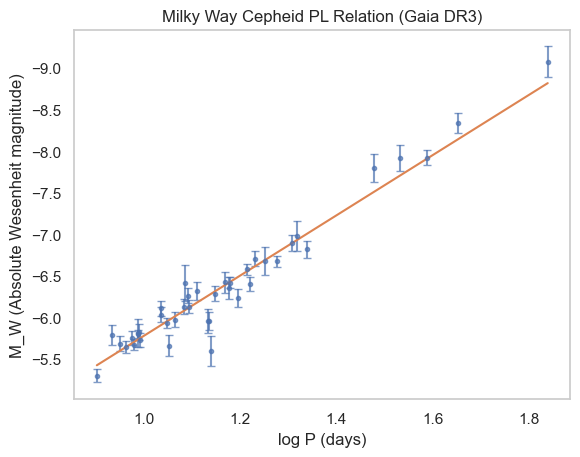

In [13]:
#data
#masking 4 w/ dodgy stats: T MON too close to saturation threshold; others too large uncertainties
#["RY VEL", "RW CAM", "SV PER", "T MON"]
#masking
#NEW BINARIES: ['FO CAR', 'MY PUP', 'R CRU', 'VY PER', 'VZ PUP']
#OLD BINARIES: ['DL CAS', 'FF AQL', 'S MUS', 'S SGE', 'SY NOR', 'TX MON', 'U VUL', 'V1334 CYG', 'YZ CAR']
#extra 2: 'X PUP', 'XX SAG'
binaries = ['FO CAR', 'MY PUP', 'R CRU', 'VY PER', 'VZ PUP', 'DL CAS', 'FF AQL', 'S MUS', 'S SGE', 'SY NOR', 'TX MON', 'U VUL', 'V1334 CYG', 'YZ CAR', 'X PUP', 'XX SAG']
mask = (df["FinalAnalysisFlag"] == 0) & (~df["Name"].isin(binaries))
df46 = df[mask].reset_index(drop=True)
logP = df46["LogPeriod"].values
mWH = df46["mWH"].values

#for using dr3
#parallax = df46["parallax_dr3"].values       # mas
#parallax_err = df46["parallax_error_dr3"].values

#for using crossmatch
parallax = df46["parallax.1"].values       # mas
parallax_err = df46["parallax_error.1"].values

#band magnitudes
m_f160w = df46["F160W"].values
m_f555w = df46["F555W"].values
m_f814w = df46["F814W"].values

#band magnitude errors
m_f160w_err = df46["F160W_error"].values
m_f555w_err = df46["F555W_error"].values
m_f814w_err = df46["F814W_error"].values

# count-rate non-linearity correction
crnl = 0.052
crnl_err = 0.014

# apparent Wesenheit magnitude
mWH_calc = m_f160w - 0.386*(m_f555w - m_f814w) + crnl    

mWH_err = np.sqrt(m_f160w_err**2 + (0.386*m_f555w_err)**2 + (0.386*m_f814w_err)**2 + crnl_err**2)
    
#P-L calibration
# M_W = m(logP − 1) + c

def PL(logP, m, c):
    return m * (logP - 1.0) + c

#corrected parallaxes
#zero_point = -0.046 #mas
#zp_err = 0.006      #mas

#zero-point calculations for dr3 using zpt package
zpt.load_tables()
zero_point_nan = zpt.get_zpt(
    df46['phot_g_mean_mag.1'], 
    df46['nu_eff_used_in_astrometry'],
    df46['pseudocolour'],
    df46['ecl_lat'],
    df46['astrometric_params_solved']
)
zero_point = np.nan_to_num(zero_point_nan, nan=np.nanmean(zero_point_nan))
zp_err = 0.0

#correcting for zero point
parallax_corr = parallax - zero_point
parallax_corr_err = np.sqrt(parallax_err**2 + zp_err**2)

#absolute Wesenheit magnitude
mu = 5*np.log10(1e3/parallax_corr) - 5
MWH = mWH_calc - mu

#error in abs M_WH
MWH_err = np.sqrt( (5/(np.log(10)) * (parallax_corr_err / parallax_corr))**2 + mWH_err**2 )

#least squares
params, cov = curve_fit(
    PL,
    logP,
    MWH,
    sigma=MWH_err,
)

#fit parameters
m, c = params
m_err, c_err = np.sqrt(np.diag(cov))

print(f"M^W_H = ({m:.3f} +- {m_err:.3f}) * (logP - 1) + ({c:.3f} +- {c_err:.3f})")
print(f'# of objects: {len(MWH)}')

#plot
plt.errorbar(logP, MWH, yerr=MWH_err, fmt='.', alpha=0.7, capsize=3)
x = np.linspace(min(logP), max(logP), 200)
plt.plot(x, PL(x, m, c))

plt.gca().invert_yaxis()
plt.xlabel("log P (days)")
plt.ylabel("M_W (Absolute Wesenheit magnitude)")
plt.title("Milky Way Cepheid PL Relation (Gaia DR3)")
plt.grid()
plt.show()

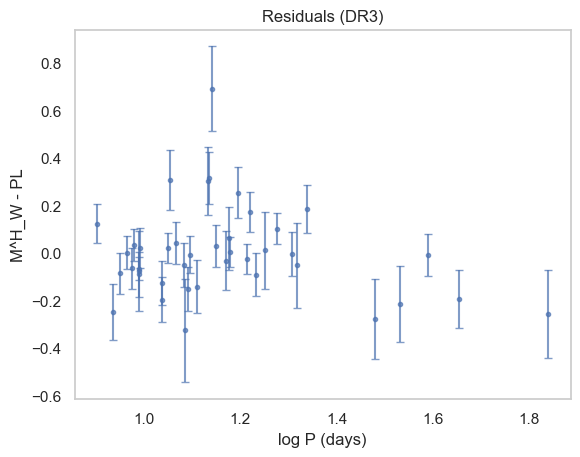

riess_col_corr_oid             16
col1                           15
F160W                       8.292
F160W_error                 0.015
F160W_nepoch                    1
                           ...   
ag_gspphot_upper           2.3509
ebpminrp_gspphot           1.2648
ebpminrp_gspphot_lower     1.2156
ebpminrp_gspphot_upper     1.2913
libname_gspphot           PHOENIX
Name: 21, Length: 247, dtype: object

In [14]:
#plotting residuals, i.e. individual magnitudes minus global fit
plt.errorbar(logP, MWH-PL(logP,m,c), yerr=MWH_err, fmt='.', alpha=0.7, capsize=3)
plt.xlabel("log P (days)")
plt.ylabel("M^H_W - PL")
plt.title("Residuals (DR3)")
plt.grid()
plt.show()

residuals = MWH-PL(logP,m,c)
np.argmax(residuals)
df46.iloc[np.argmin(residuals)]

In [15]:
#%run riess_copy.py

In [16]:
from PL_relations import PL_relation_ls_fit

M^W_H = (-3.627 +- 0.126) * (logP - 1) + (-5.777 +- 0.026)


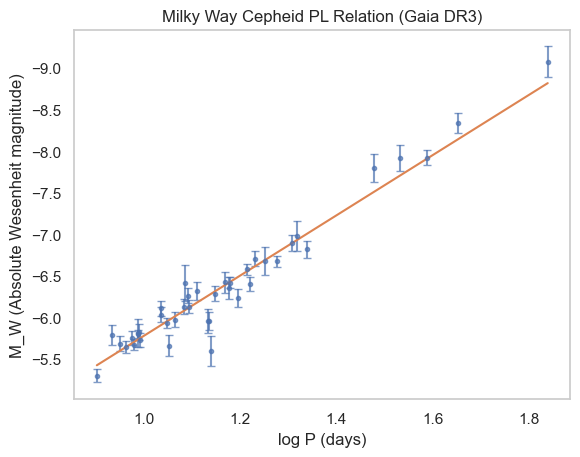

(-3.6268775436664593,
 -5.777472233671938,
 array([1.095, 1.232, 1.532, 0.98 , 1.276, 1.179, 1.589, 1.111, 0.99 ,
        0.989, 0.992, 0.903, 1.252, 1.479, 1.221, 0.964, 1.053, 0.935,
        1.318, 0.976, 1.149, 1.086, 1.196, 0.951, 1.136, 0.989, 1.133,
        1.839, 1.037, 1.653, 1.17 , 1.214, 1.066, 1.049, 1.084, 1.092,
        1.308, 1.339, 1.177, 1.141, 1.037]),
 array([-6.12929163, -6.70945924, -7.92234312, -5.67147193, -6.67611123,
        -6.42125724, -7.92197337, -6.32103481, -5.83010506, -5.81366029,
        -5.72663239, -5.3017019 , -6.68056044, -7.79400664, -6.40471005,
        -5.64553721, -5.66276202, -5.79038603, -6.98315295, -5.75454504,
        -6.28758662, -6.41562699, -6.23327157, -5.68508482, -5.95498283,
        -5.80296078, -5.95534284, -9.07647833, -6.10894642, -8.33960846,
        -6.42550546, -6.57923376, -5.97430978, -5.93482995, -6.13189946,
        -6.26209065, -6.89726571, -6.82073287, -6.35791186, -5.59620787,
        -6.03642394]),
 array([0.07748548, 0

In [17]:
PL_relation_ls_fit(dr=3)

M^W_H = (-3.367 +- 0.172) * (logP - 1) + (-5.857 +- 0.044)


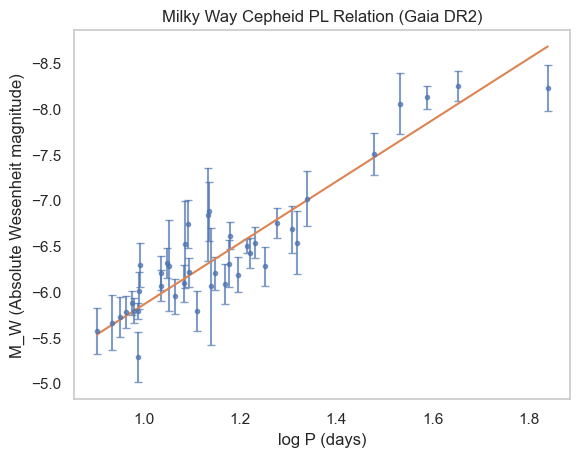

(-3.366540505576826,
 -5.856695659048101,
 array([1.095, 1.232, 1.532, 0.98 , 1.276, 1.179, 1.589, 1.111, 0.99 ,
        0.989, 0.992, 0.903, 1.252, 1.479, 1.221, 0.964, 1.053, 0.935,
        1.318, 0.976, 1.149, 1.086, 1.196, 0.951, 1.136, 0.989, 1.133,
        1.839, 1.037, 1.653, 1.17 , 1.214, 1.066, 1.049, 1.084, 1.092,
        1.308, 1.339, 1.177, 1.141, 1.037]),
 array([-6.21386617, -6.5351521 , -8.05691549, -5.79103913, -6.74962661,
        -6.61286117, -8.12666504, -5.78593759, -6.0076985 , -5.28304684,
        -6.29171731, -5.56979798, -6.27800805, -7.50371574, -6.4180961 ,
        -5.77407339, -6.28491023, -5.66098984, -6.53629896, -5.87588854,
        -6.19991513, -6.51623845, -6.18591164, -5.71965729, -6.87763324,
        -5.7859821 , -6.84139471, -8.2261956 , -6.20251736, -8.24899993,
        -6.08360675, -6.49432534, -5.94658094, -6.31036689, -6.09196997,
        -6.73594902, -6.68189939, -7.01684662, -6.3069799 , -6.05719758,
        -6.06599966]),
 array([0.15858491, 0.

In [18]:
PL_relation_ls_fit()

# Distances with $<s>$

0.034852360923523146


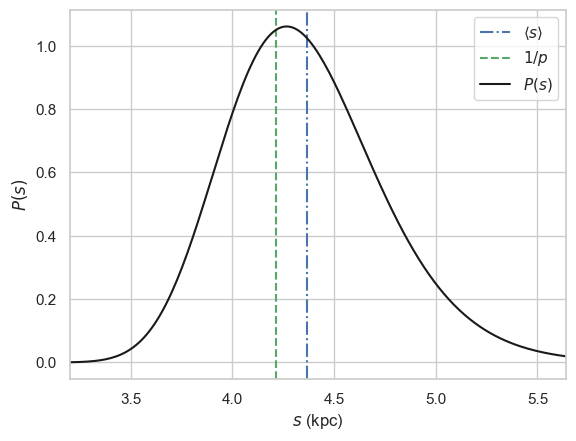

In [48]:
# constants (kpc)
#density function
R0 = 8.2        # Sun galactocentric radius
Rd = 3
z0 = 0.3
z0_t = 0.9
a_t = 0.12
a_h = 0.001

#selection function testing (ignore these)
a = 0.112
c1 = 1.37
d1 = 9.52
d2 = 1.3
c2 = 6.51

# distance grid (kpc)
s = np.linspace(0.001, 25.0, 2000)

#--------------------------------------------------
#gaussian likelihood for parallax (G)
def parallax_likelihood(p, p0, sigma_p):
    return np.exp(-0.5 * ((p - p0) / sigma_p)**2)

#-------------------------------------------------
#density prior (rho)
def density_prior(s, l, b):
    """
    s in kpc
    l, b in radians
    """
    # convert heliocentric distance -> galactocentric coordinates
    x = R0 - s * np.cos(b) * np.cos(l)
    y = -s * np.cos(b) * np.sin(l)
    z = s * np.sin(b)

    R = np.sqrt(x**2 + y**2)
    r = np.sqrt(R**2 + z**2)

    thin = np.exp(-(R - R0) / Rd) * np.exp(-np.abs(z) / z0)
    thick = a_t * np.exp(-(R - R0) / Rd) * np.exp(-np.abs(z) / z0_t)
    halo = a_h * (r / R0) ** (-2.5)

    return thin #+ thick + halo

#-------------------------------------------------
#IGNORE THIS SELECTION FUNCTION

def selection_function(s):
    S = 1                       #d2*np.exp(-s*c2) + d1*(np.exp(-((np.log(s)-np.log(a))*c1)**2/2))
    return S

#--------------------------------------------------
#distance expectation (<s>)

def bayesian_distance(parallax_mas, parallax_err_mas, l_deg, b_deg):
    """
    Returns expected distance in kpc
    """
    # convert units
    p0 = parallax_mas
    sigma_p = parallax_err_mas
    l = np.radians(l_deg)
    b = np.radians(b_deg)

    # parallax corresponding to distance
    p = 1.0 / s  # mas if s in kpc

    #priors
    G = parallax_likelihood(p, p0, sigma_p)
    rho = density_prior(s, l, b)
    S = selection_function(s)

    #normalisation
    N = trapezoid(s**2 * G * rho * S, x=s)

    posterior = (s**2 * G * rho * S) / N
        
    dist_exp = trapezoid(s**3 * G * rho * S, x=s) / N

    #sigma
    cdf = cumulative_trapezoid(posterior, s, initial=0)
    cdf /= cdf[-1]  #normalisation
    dist_err = np.maximum(np.interp(0.5,cdf,s) - np.interp(0.16,cdf,s), np.interp(0.84,cdf,s) - np.interp(0.5,cdf,s))
    
    return dist_exp, dist_err, posterior

#for plotting an individual posterior distribution
longs = df46['l']
lats = df46['b']
name = df46['Name']
eg = 27

#calculating full distances
distances = np.array([
    bayesian_distance(p, pe, l, b)[0]
    for p, pe, l, b in zip(parallax_corr,parallax_corr_err,longs,lats)
])

distances_err = np.array([
    bayesian_distance(p, pe, l, b)[1]
    for p, pe, l, b in zip(parallax_corr,parallax_corr_err,longs,lats)
])

#print(distances_err/distances)
#print(parallax_corr_err/parallax_corr)
#print(np.argmax(distances_err/distances))
#print(df46.iloc[np.argmax(distances_err/distances)])

#plotting
posterior_test = bayesian_distance(parallax_corr[eg], parallax_corr_err[eg], longs[eg], lats[eg])[2]
print((distances[eg]-1/parallax_corr[eg])/distances[eg])
plt.figure()
sns.set_theme(style="whitegrid")
#plt.title(f'Distance distribution for Cepheid {name[eg]}, with $\sigma_p / p$ ~ {parallax_corr_err[eg]/parallax_corr[eg]:.2f}')
plt.ylabel(f'$P(s)$')
plt.xlabel(f'$s$ (kpc)')
plt.axvline(distances[eg], label = r"$\langle s \rangle$", linestyle='-.',color='b')
plt.axvline(1/parallax_corr[eg], label=r"$1/p$", linestyle='--', color='g')
plt.xlim(s[posterior_test > 0.1].min()-0.4, s[posterior_test > 0.1].max()+0.4)
sns.lineplot(x=s, y=posterior_test, label=r'$P(s)$',color='k');
plt.legend();
plt.savefig('eg_posterior.pdf')

# of objects: 41


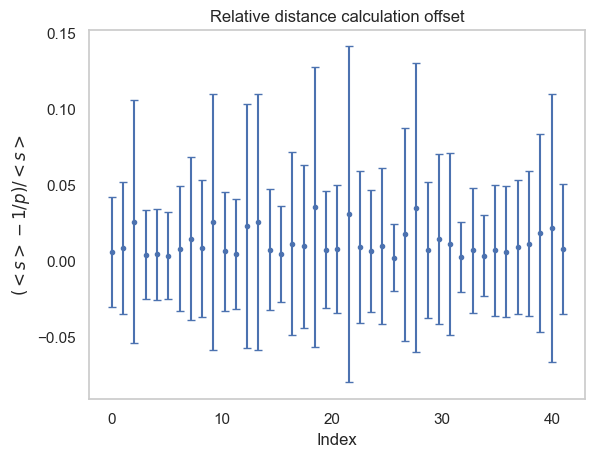

In [24]:
#rel_dist_err = np.sqrt((parallax_corr_err/parallax_corr**2)+(distances_err/distances**2))
rel_dist = (distances-1/parallax_corr)/distances
rel_dist_err = distances_err/distances

plt.title('Relative distance calculation offset')
plt.grid()
plt.xlabel('Index')
plt.ylabel(f'$(<s> - 1/p) / <s>$')
plt.errorbar(np.linspace(0,len(distances),len(distances)),rel_dist,yerr=rel_dist_err, fmt='.',capsize=3);

mu2 = 5*np.log10(distances) + 10
MWH2 = mWH_calc - mu2
#print(distances)

print(f'# of objects: {len(distances)}')

1/p:
M^W_H = (-3.627 +- 0.126) * (logP - 1) + (-5.777 +- 0.026)
# of objects: 41
<s>:
M^W_H = (-3.656 +- 0.127) * (logP - 1) + (-5.789 +- 0.026)


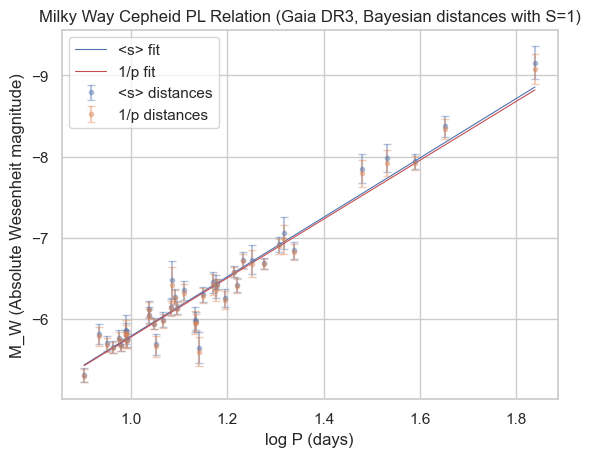

In [137]:
#error in abs M_WH
MWH_err2 = np.sqrt( (5/(np.log(10)) * (distances_err / distances))**2 + mWH_err**2 )

#least squares
params2, cov2 = curve_fit(
    PL,
    logP,
    MWH2,
    sigma=MWH_err2
)

m2, c2 = params2
m_err2, c_err2 = np.sqrt(np.diag(cov2))

print('1/p:')
print(f"M^W_H = ({m:.3f} +- {m_err:.3f}) * (logP - 1) + ({c:.3f} +- {c_err:.3f})")
print(f'# of objects: {len(MWH)}')
print('<s>:')
print(f"M^W_H = ({m2:.3f} +- {m_err2:.3f}) * (logP - 1) + ({c2:.3f} +- {c_err2:.3f})")

#print(MWH2[39])
#print()

#plot
#plt.figure(figsize=(12,8))
plt.errorbar(logP, MWH2, yerr=MWH_err2, fmt='.', alpha=0.4, capsize=3, label='<s> distances')
x = np.linspace(min(logP), max(logP), 200)
plt.plot(x, PL(x, m2, c2), label='<s> fit', linewidth=0.8, color='b')

plt.errorbar(logP, MWH, yerr=MWH_err, fmt='.', alpha=0.4, capsize=3, label='1/p distances')
plt.plot(x, PL(x, m, c), label='1/p fit', linewidth=0.8, color='r')

plt.gca().invert_yaxis()
plt.xlabel("log P (days)")
plt.ylabel("M_W (Absolute Wesenheit magnitude)")
plt.title("Milky Way Cepheid PL Relation (Gaia DR3, Bayesian distances with S=1)")
plt.legend()
plt.show();

c:\users\joshu\appdata\local\programs\python\python39\lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


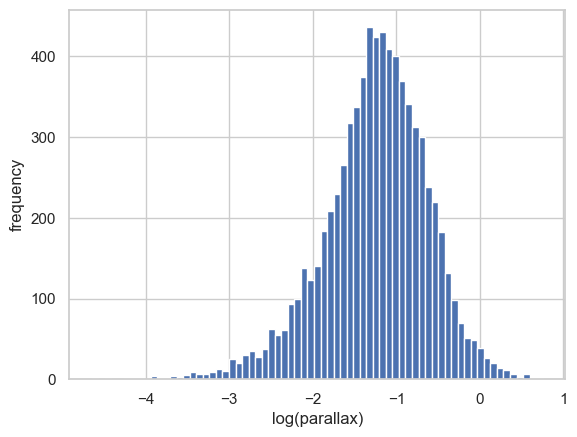

In [26]:
#histogram of ALL dr3 parallaxes
plt.hist(np.log10(dr3['parallax']), bins='fd');
plt.xlabel('log(parallax)')
plt.ylabel('frequency');

In [138]:
# new density of thin disc only

def density_thin(s,l,b, Rd):

    z = s*np.sin(b)

    R = np.sqrt(R0**2 + (s*np.cos(b))**2 - 2*R0*s*np.cos(b)*np.cos(l))

    rho = np.exp(-(R-R0)/Rd) * np.exp(-np.abs(z)/z0)

    return rho

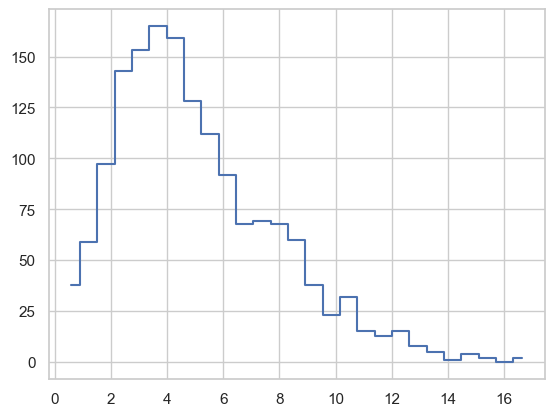

In [28]:
#parallax cuts for histogram
mask_hist = ((dr3['parallax_error']/dr3['parallax'] < 0.2) & (dr3['parallax'] > 0) & (dr3['b'] > -20))
dr3_masked_hist = dr3[mask_hist]
dr3_coords_masked = dr3_coords[mask_hist]
hist_obs, edges = np.histogram(1/dr3_masked_hist['parallax'], bins='fd')
s_mid = 0.5*(edges[1:]+edges[:-1])

#step plot
plt.step(s_mid, hist_obs, where="mid", label="Observed")


In [29]:
#imports for mcmc sampling

from scipy.optimize import minimize
import emcee
import corner
from astroML.plotting.mcmc import plot_mcmc

c:\users\joshu\appdata\local\programs\python\python39\lib\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


In [30]:
#sigmoid-type selection function
def S_tanh(s, s_lim, width, skew):
    return (1 - np.tanh((s - s_lim) / width))**skew

l = dr3_coords_masked.galactic.l.value
b = dr3_coords_masked.galactic.b.value
R0 = 8.2
z0 = 0.3

#thin disc density (Rd as parameter here for mcmc)
def mean_density(s,Rd):

    s = s[:,None]

    z = s * np.sin(b)
    
    R = np.sqrt(
        R0**2
        + (s*np.cos(b))**2
        - 2*R0*s*np.cos(b)*np.cos(l)
    )

    rho = np.exp(-(R-R0)/Rd) * np.exp(-np.abs(z)/z0)

    return rho.mean(axis=1)

#model pdf
def model_pdf(s, params):

    Rd, s_lim, width, skew = params

    rho = mean_density(s, Rd)

    pdf = s**2 * rho * S_tanh(s, s_lim, width, skew)

    norm = np.trapz(pdf, s)

    return pdf / norm

#likelihood
def loglike(params):

    pdf = model_pdf(s, params)

    p = np.interp(1/dr3_masked_hist['parallax'].values, s, pdf)

    p[p <= 0] = 1e-12

    return np.sum(np.log(p))

#prior
def logprior(params):

    Rd, s_lim, width, skew = params

    if 1 < Rd < 5 and 0.5 < s_lim < 10 and 0.1 < width < 5 and 0.1 < skew < 2:
        return 0

    return -np.inf

#posterior
def logposterior(params):

    lp = logprior(params)

    if not np.isfinite(lp):
        return -np.inf

    return lp + loglike(params)


In [106]:
# no. of dimensions and walkers for mcmc
ndim = 4
nwalkers = 32
#initial guesses
p0 = np.array([4.7, 2.7, 0.9, 0.2])

pos = p0 + 1e-3*np.random.randn(nwalkers, ndim)

#ensemble sampling
sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    logposterior
)

sampler.run_mcmc(pos, 1000, progress=True);

100%|████████████████████████████████████████████████████████████████████████████| 1000/1000 [1:50:18<00:00,  6.62s/it]


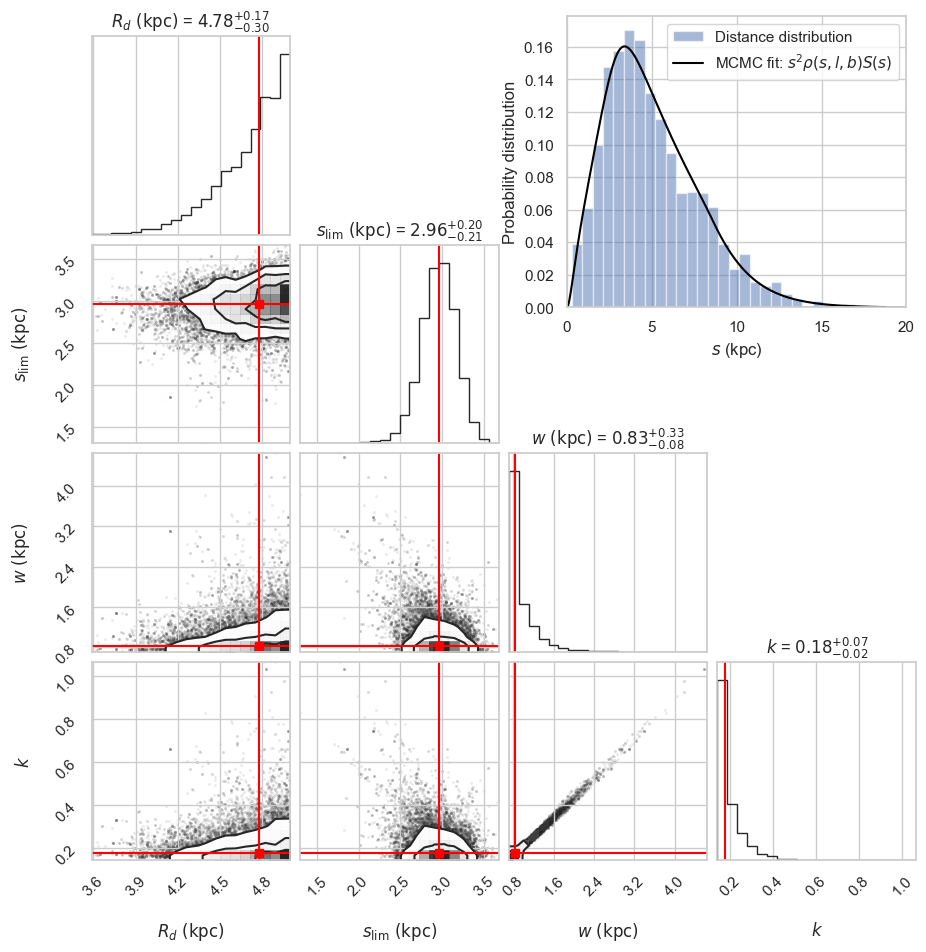

In [107]:
samples = sampler.get_chain(discard=100, flat=True)

Rd_samples = samples[:,0]
s_lim_samples = samples[:,1]
width_samples = samples[:,2]
skew_samples = samples[:,3]

#corner.corner(
#    samples,
#    labels=["Scale length of disc","Limiting distance","Width","Skewness"]
#);

labels = [
    r"$R_d\ (\mathrm{kpc})$",
    r"$s_\mathrm{lim}\ (\mathrm{kpc})$",
    r"$w\ (\mathrm{kpc})$",
    r"$k$"
]

#median and 1-sigma
medians = np.median(samples, axis=0)
lower = np.percentile(samples, 16, axis=0)
upper = np.percentile(samples, 84, axis=0)

#corner plot
fig = corner.corner(
    samples,
    labels=labels,
    truths=medians,
    truth_color='red',
    show_titles=True,
    title_fmt=".2f",
    title_kwargs={"fontsize": 12}
)

fig.subplots_adjust(bottom=0.1, top=0.95,
                left=0.1, right=0.95,
                hspace=0.05, wspace=0.05)

best = np.median(samples, axis=0)

pdf = model_pdf(s, best)
ax = fig.add_axes([0.59, 0.67, 0.35, 0.3])
ax.hist(1/dr3_masked_hist['parallax'].values, bins="fd", density=True, alpha=0.5, label='Distance distribution')
ax.plot(s, pdf, label=r'MCMC fit: $s^2 \rho (s,l,b) S(s)$', color='black')

ax.set_xlabel("$s$ (kpc)")
ax.set_xlim(0,20)
ax.set_ylabel("Probability distribution")
ax.legend();

plt.savefig('mcmc.pdf')

1569


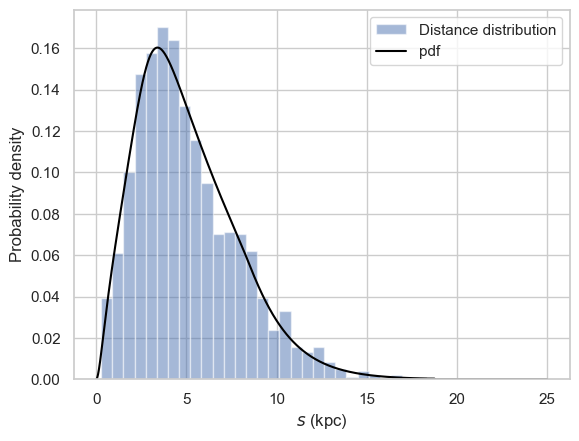

In [129]:
best = np.median(samples, axis=0)

pdf = model_pdf(s, best)

plt.hist(1/dr3_masked_hist['parallax'].values, bins="fd", density=True, alpha=0.5, label='Distance distribution')
plt.plot(s, pdf, label='pdf', color='black')

plt.xlabel("$s$ (kpc)")
plt.ylabel("Probability density")
plt.legend();

print(len(dr3_masked_hist['parallax']));

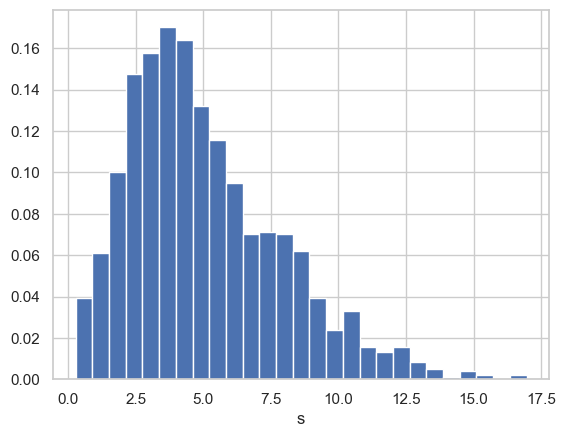

In [135]:
#plotting distances of suitable latitudes
df_landb = pd.read_csv("incl. l and b-result.csv")
mask_lb = ((df_landb['b'] > -20) & (df_landb['parallax_error']/df_landb['parallax'] < 0.2) & (df_landb['parallax']>0))
df_landb = df_landb[mask_lb]
plt.hist(1/df_landb['parallax'].values, bins="fd", density=True);
plt.xlabel('s');

1/p:
M^W_H = (-3.627 +- 0.126) * (logP - 1) + (-5.777 +- 0.026)
# of objects: 41
<s>:
M^W_H = (-3.656 +- 0.127) * (logP - 1) + (-5.789 +- 0.026)


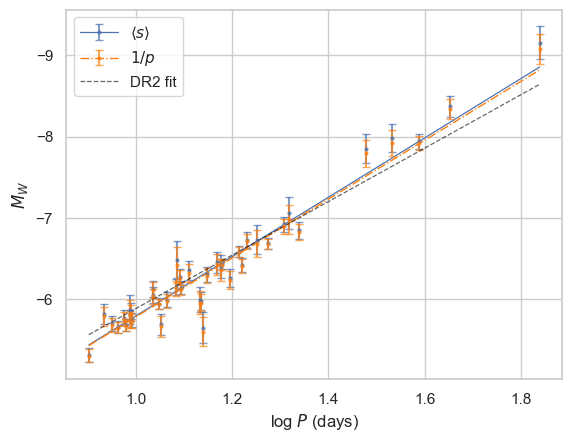

In [110]:
#copy of previous distance estimation except with mcmc parameters
def bayesian_distance2(parallax_mas, parallax_err_mas, l_deg, b_deg, best):
    """
    Returns expected distance in kpc
    """
    # convert units
    p0 = parallax_mas
    sigma_p = parallax_err_mas
    l = np.radians(l_deg)
    b = np.radians(b_deg)

    # parallax corresponding to distance
    p = 1.0 / s  # mas if s in kpc

    G = parallax_likelihood(p, p0, sigma_p)
    rho = density_thin(s, l, b, best[0])
    S = S_tanh(s,best[1],best[2],best[3])

    N = trapezoid(s**2 * G * rho * S, x=s)

    posterior = (s**2 * G * rho * S) / N
        
    dist_exp = trapezoid(s**3 * G * rho * S, x=s) / N

    #sigma
    cdf = cumulative_trapezoid(posterior, s, initial=0)
    cdf /= cdf[-1]  #normalisation
    dist_err = np.maximum(np.interp(0.5,cdf,s) - np.interp(0.16,cdf,s), np.interp(0.84,cdf,s) - np.interp(0.5,cdf,s))
    
    return dist_exp, dist_err, posterior


longs = df46['l']
lats = df46['b']
name = df46['Name']
eg = 27

distances = np.array([
    bayesian_distance2(p, pe, l, b, best)[0]
    for p, pe, l, b in zip(parallax_corr,parallax_corr_err,longs,lats)
])

distances_err = np.array([
    bayesian_distance2(p, pe, l, b, best)[1]
    for p, pe, l, b in zip(parallax_corr,parallax_corr_err,longs,lats)
])

#error in abs M_WH
MWH_err2 = np.sqrt( (5/(np.log(10)) * (distances_err / distances))**2 + mWH_err**2 )

#least squares
params2, cov2 = curve_fit(
    PL,
    logP,
    MWH2,
    sigma=MWH_err2
)

m2, c2 = params2
m_err2, c_err2 = np.sqrt(np.diag(cov2))

print('1/p:')
print(f"M^W_H = ({m:.3f} +- {m_err:.3f}) * (logP - 1) + ({c:.3f} +- {c_err:.3f})")
print(f'# of objects: {len(MWH)}')
print('<s>:')
print(f"M^W_H = ({m2:.3f} +- {m_err2:.3f}) * (logP - 1) + ({c2:.3f} +- {c_err2:.3f})")

#print(MWH2[39])
#print()

#plot
#plt.figure(figsize=(12,8))
#<s> distances
s_points = plt.errorbar(logP, MWH2, yerr=MWH_err2, fmt='.', alpha=0.7, capsize=3,color='b',ms=4)
x = np.linspace(min(logP), max(logP), 200)
s_line, = plt.plot(x, PL(x, m2, c2), linewidth=0.9, color='b')
#1/p distances
p_points = plt.errorbar(logP, MWH, yerr=MWH_err, fmt='.', alpha=0.7, capsize=3,color='tab:orange',ms=4)
p_line, = plt.plot(x, PL(x, m, c), linewidth=1, color='tab:orange', linestyle='-.')

other_line, = plt.plot(x, PL(x, m_rc, c_rc), linewidth=0.9, color='black', linestyle='--', alpha=0.6)

plt.gca().invert_yaxis()
plt.xlabel(r"log $P$ (days)")
plt.ylabel(r"$M_W$")
#plt.title("Milky Way Cepheid PL Relation (Gaia DR3, Bayesian distances)")
plt.legend(
    [(s_points,s_line),(p_points,p_line),other_line],
    [r'$\langle s \rangle$',r'$1/p$','DR2 fit'],
    fontsize=11,
    handlelength=2.5
)
plt.savefig('pl_final.pdf')

In [127]:
#parameters to compare to other results
#Riess et al., 2018b
m_r = -3.26
c_r = -5.93
H0_pref = 73.24
H0_mw = 76.18

#my dr2 fit
m_rc = -3.294
c_rc = -5.88

dPL = (m2*(np.mean(logP)-1) + c2) - (m_r*(np.mean(logP)-1) + c_r)
#fainter cepheids => mu smaller => closer => less expansion => H_0 decreases
dPL_percent = dPL/np.abs((m_r*(np.mean(logP)-1) + c_r))

dH0 = 10**(dPL/5) - 1   #factor of H0

H0_new = (dH0+1)*H0_mw

print(f"delta M_W = {dPL:.3f} ~ {dPL_percent*100:.2f}%")
print(f"{dH0*100:.2f}% change in H0")
print(f"to {H0_new:.2f} (from 1 anchor, MW Cepheids {H0_mw})")
print(f"or to {(dH0+1)*H0_pref:.2f} (from preferred, 3 anchors {H0_pref})")

delta M_W = 0.074 ~ 1.15%
3.48% change in H0
to 78.83 (from 1 anchor, MW Cepheids 76.18)
or to 75.79 (from preferred, 3 anchors 73.24)


## Additional figures (not necessarily) used

M^W_H = (-3.294 +- 0.164) * (logP - 1) + (-5.880 +- 0.041)


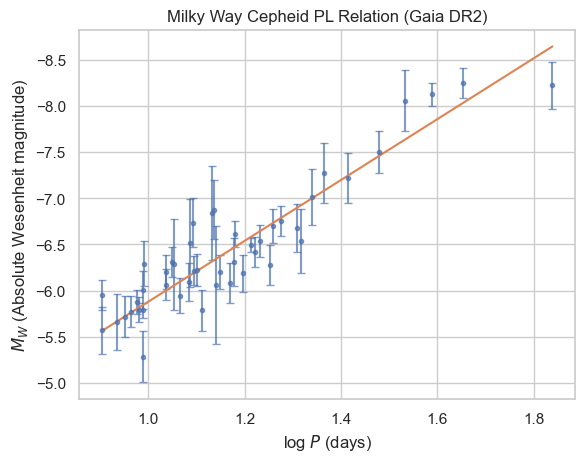

In [272]:
#%run riess_copy.py

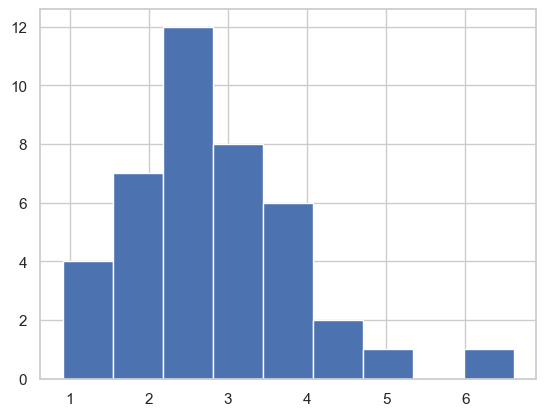

In [135]:
plt.hist(distances, bins='fd');

In [5]:
from PL_relations import PL_relation_ls_fit
def PL(logP, m, c):
    return m * (logP - 1.0) + c

M^W_H = (-3.551 +- 0.138) * (logP - 1) + (-5.787 +- 0.029)


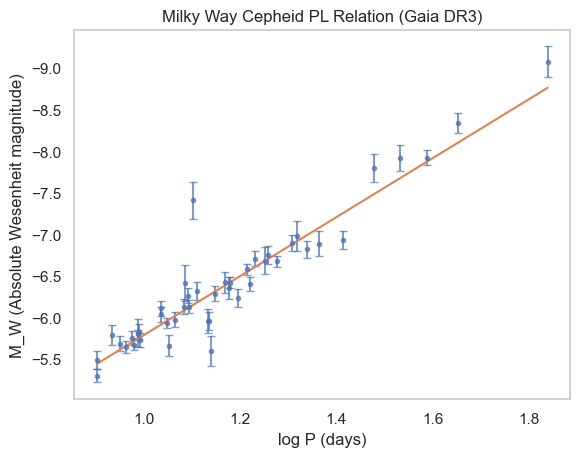

M^W_H = (-3.627 +- 0.126) * (logP - 1) + (-5.777 +- 0.026)


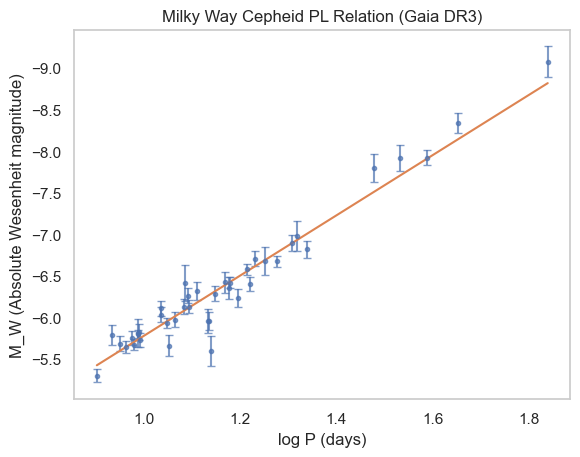

In [42]:
#with and without binaries
mb, cb, logPb, MWHb, MWH_errb = PL_relation_ls_fit(dr=3, mask_binaries=False)
mnb, cnb, logPnb, MWHnb, MWH_errnb = PL_relation_ls_fit(dr=3)

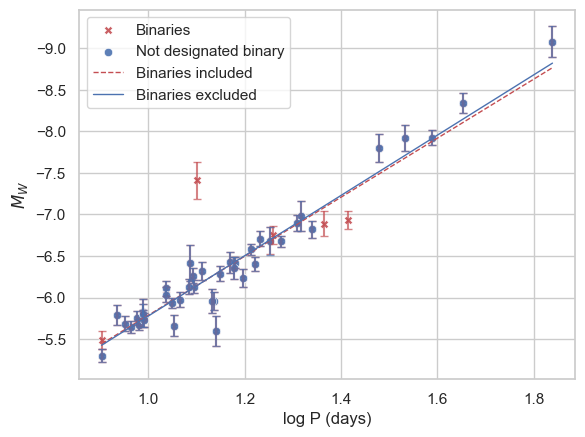

In [49]:
sns.set_theme(style="whitegrid")

xb = np.linspace(min(logPb), max(logPb), 200)
xnb = np.linspace(min(logPnb), max(logPnb), 200)

# Scatter points
sns.scatterplot(x=logPb, y=MWHb, color='r', alpha=0.9, label='Binaries', marker='X')
sns.scatterplot(x=logPnb, y=MWHnb, color='b', alpha=0.9, label='Not designated binary', marker='o')

# Error bars
plt.errorbar(logPb, MWHb, yerr=MWH_errb, fmt='none', color='r', capsize=3, alpha=0.7)
plt.errorbar(logPnb, MWHnb, yerr=MWH_errnb, fmt='none', color='b', capsize=3, alpha=0.7)

# PL fits
sns.lineplot(x=xb, y=PL(xb, mb, cb), color='r', label='Binaries included', linewidth=1, linestyle='--')
sns.lineplot(x=xnb, y=PL(xnb, mnb, cnb), color='b', label='Binaries excluded', linewidth=1)

plt.gca().invert_yaxis()

plt.xlabel("log P (days)")
plt.ylabel(f"$M_W$")

plt.savefig('binaries.pdf');

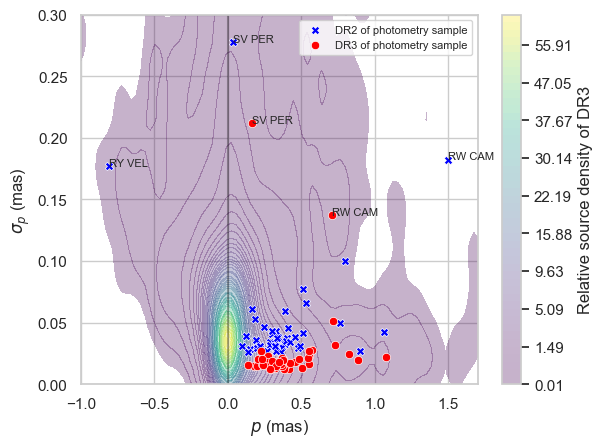

In [52]:
#kde plot

dr3_clean = dr3[
    (np.isfinite(dr3['parallax'])) &
    (np.isfinite(dr3['parallax_error'])) &
    (dr3['parallax_error'] < 1) &
    (dr3['parallax'] > -2) &
    (dr3['parallax'] < 5)
]

sns.kdeplot(x=dr3_clean['parallax'], y=dr3_clean['parallax_error'], fill=True,cmap='viridis',levels=50,thresh=0.01,alpha=0.3,cbar=True,cbar_kws={'label':'Relative source density of DR3'})
#plt.hexbin(x=dr3_clean['parallax'], y=dr3_clean['parallax_error'], gridsize=200,cmap='Greys',bins='log')
sns.scatterplot(x=dr2['parallax'], y=dr2['parallax_error'], label='DR2 of photometry sample', marker='X',color='blue')
sns.scatterplot(x=cross['parallax.1'], y=cross['parallax_error.1'], label='DR3 of photometry sample',color='red')

# label points with high sigma_p in dr2
mask1 = dr2['parallax_error'] > 0.11
#mask1 = dr2["FinalAnalysisFlag"] == 1

for _, row in dr2[mask1].iterrows():
    plt.text(row['parallax'], row['parallax_error'], row['Name'],
             fontsize=8)

# label points with high sigmap in cross
mask2 = cross['parallax_error.1'] > 0.11
#mask2 = cross["FinalAnalysisFlag"] == 1

for _, row in cross[mask2].iterrows():
    plt.text(row['parallax.1'], row['parallax_error.1'], row['Name'],
             fontsize=8)
plt.axvline(0, color='black', alpha=0.3)
plt.xlabel(f"$p$ (mas)")
plt.ylabel(f"$\sigma_p$ (mas)")
plt.ylim(0,0.3)
plt.xlim(-1,1.7)
plt.legend(prop={'size':8});

plt.savefig('errors_comparison.pdf')

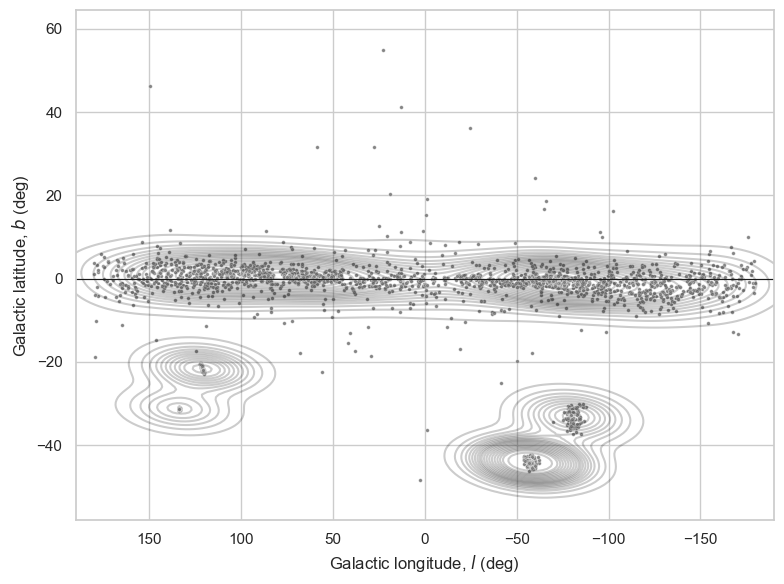

In [53]:
#%run plot_gaia_z.py
%run plot_gaia_z_sns.py

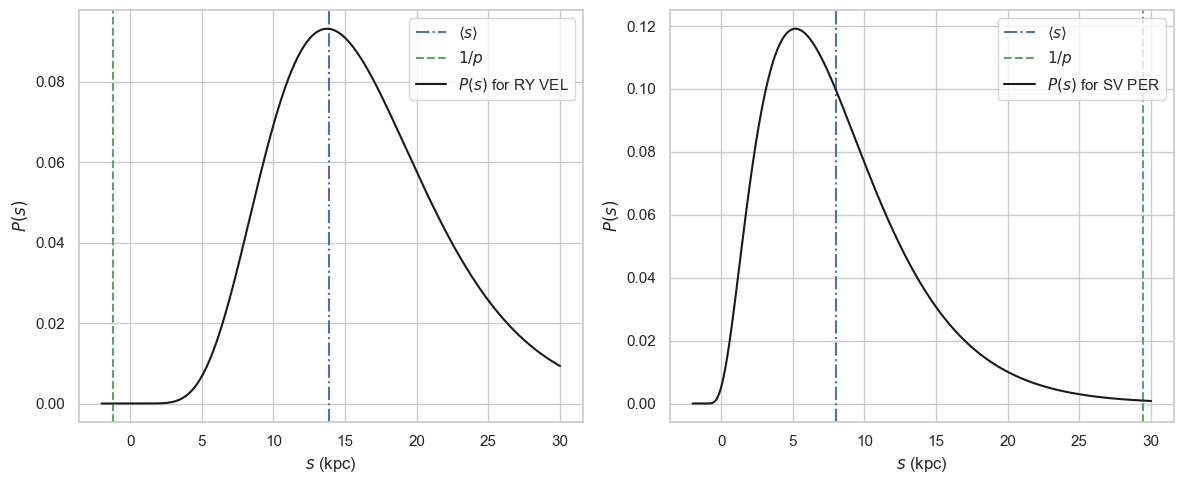

In [51]:
#same as plotting posterior distributions as above but for two
pdr2 = dr2['parallax']
perrdr2 = dr2['parallax_error']
ldr2 = dr2['l']
bdr2 = dr2['b']
sdr2 = np.linspace(-2.0, 30.0, 2000)

distances_dr2 = np.array([
    bayesian_distance(p, pe, l, b)[0]
    for p, pe, l, b in zip(dr2['parallax'],dr2['parallax_error'],dr2['l'],dr2['b'])
])

distances_err_dr2 = np.array([
    bayesian_distance(p, pe, l, b)[1]
    for p, pe, l, b in zip(dr2['parallax'],dr2['parallax_error'],dr2['l'],dr2['b'])
])

#examples to plot
egdr2 = [21,25]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

for ax, eg in zip(axes, egdr2):

    posterior_testdr2 = bayesian_distance(
        pdr2[eg], perrdr2[eg], ldr2[eg], bdr2[eg]
    )[2]

    ax.set_ylabel(r'$P(s)$')
    ax.set_xlabel(r'$s$ (kpc)')

    ax.axvline(distances_dr2[eg],
               label=r"$\langle s \rangle$",
               linestyle='-.', color='b')

    ax.axvline(1/pdr2[eg],
               label=r"$1/p$",
               linestyle='--', color='g')

    sns.lineplot(x=sdr2, y=posterior_testdr2, ax=ax,
                 label=fr"$P(s)$ for {dr2['Name'][eg]}", color='k')

    ax.legend()

plt.tight_layout()
plt.savefig('bad_inv_p.pdf')

In [123]:
#radial velocities
rv = pd.to_numeric(df46['radial_velocity'],errors='coerce')
np.mean(abs(rv))/299792

8.465640301266935e-05